In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------------------------------------
# Repo-specific imports

# Add the repo root (e.g.,/fairmast-data-preprocessing) to sys.path
REPO_ROOT = os.path.abspath(os.path.join(
    os.path.dirname(__file__) if '__file__' in globals() else os.getcwd(),
    ".."))  # noqa: E402
print(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.MAST_tools.MAST_dataset import MastDataset
from scripts.pipelines.utils.utils import ComposeTransforms

from scripts.pipelines.transforms.signal_level_transforms.reshape_lcfs_transform import (
ReshapeLcfsTransform
)


# ----------------------------------------------------------------------------------------------------------------------
# Determine device to train on

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

/home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing


In [2]:
LOCAL_FLAG = True
train_sh = [14960, 15653, 23172]
source_signal_list_ = [('equilibrium','lcfs_r'), 
                       ('equilibrium','lcfs_z')]

In [3]:
# ..................................................................................................................
# Specific Data Preprocessing for LCFS profiles 

signal_transform_map = {
    var: ComposeTransforms([ReshapeLcfsTransform()]) 
    for var in [f'{source}-{signal}' for source, signal in source_signal_list_] }

non_preprocessed_train_dataset = MastDataset(
    local=LOCAL_FLAG,
    shots_list=train_sh,
    source_signal_list=source_signal_list_,
    signal_level_transform_map=None,
    shot_level_transform=None
)

preprocessed_train_dataset = MastDataset(
    local=LOCAL_FLAG,
    shots_list=train_sh,
    source_signal_list=source_signal_list_,
    signal_level_transform_map=signal_transform_map,
    shot_level_transform=None
)

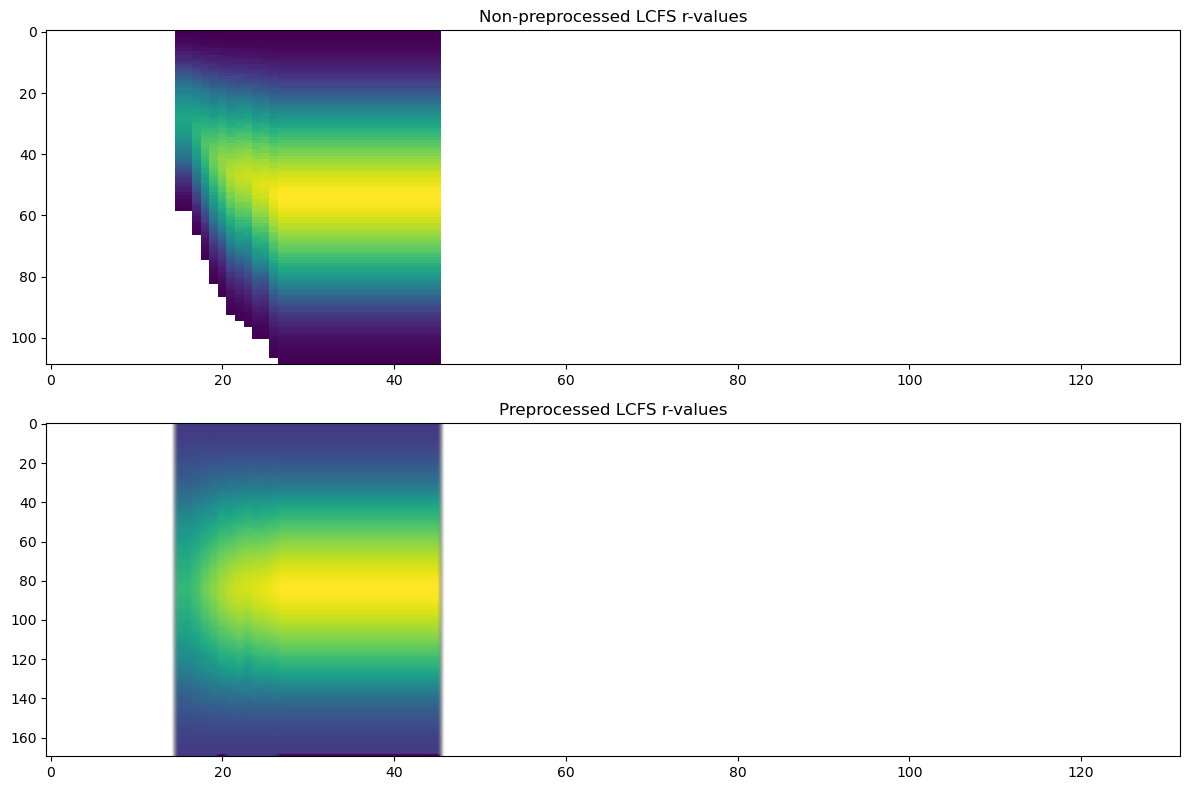

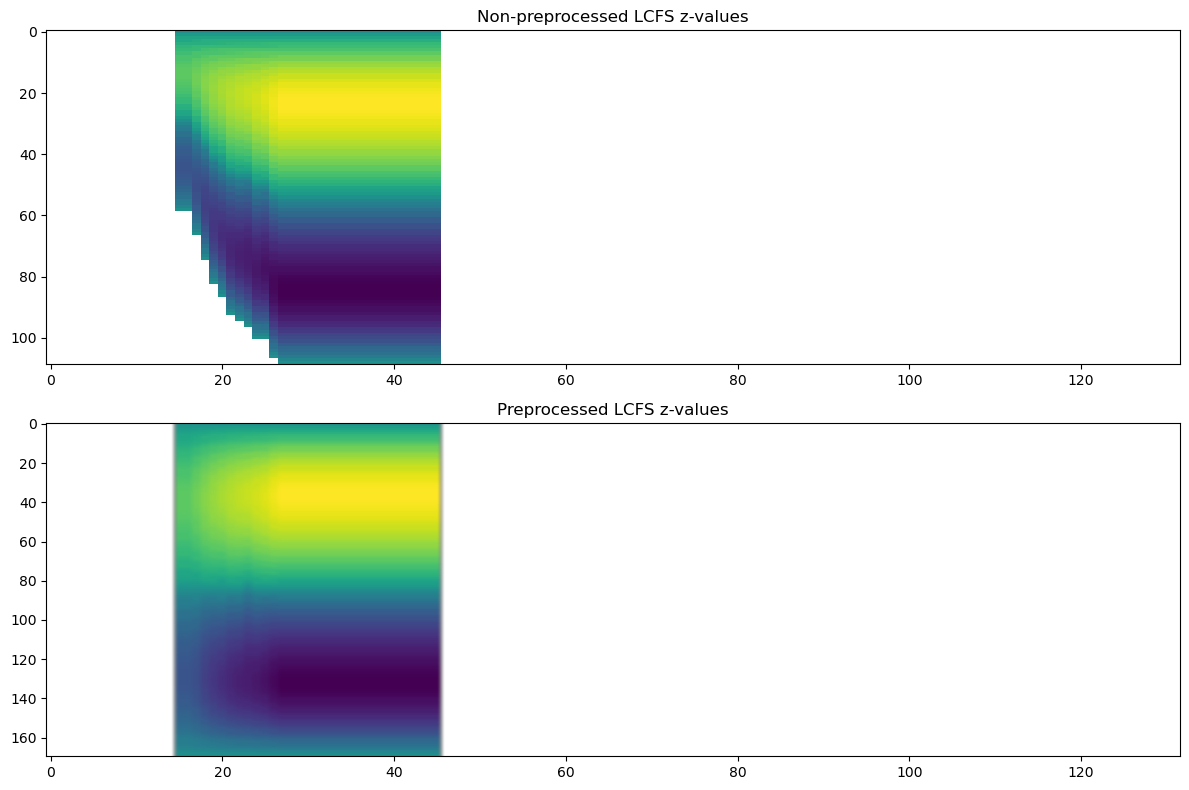

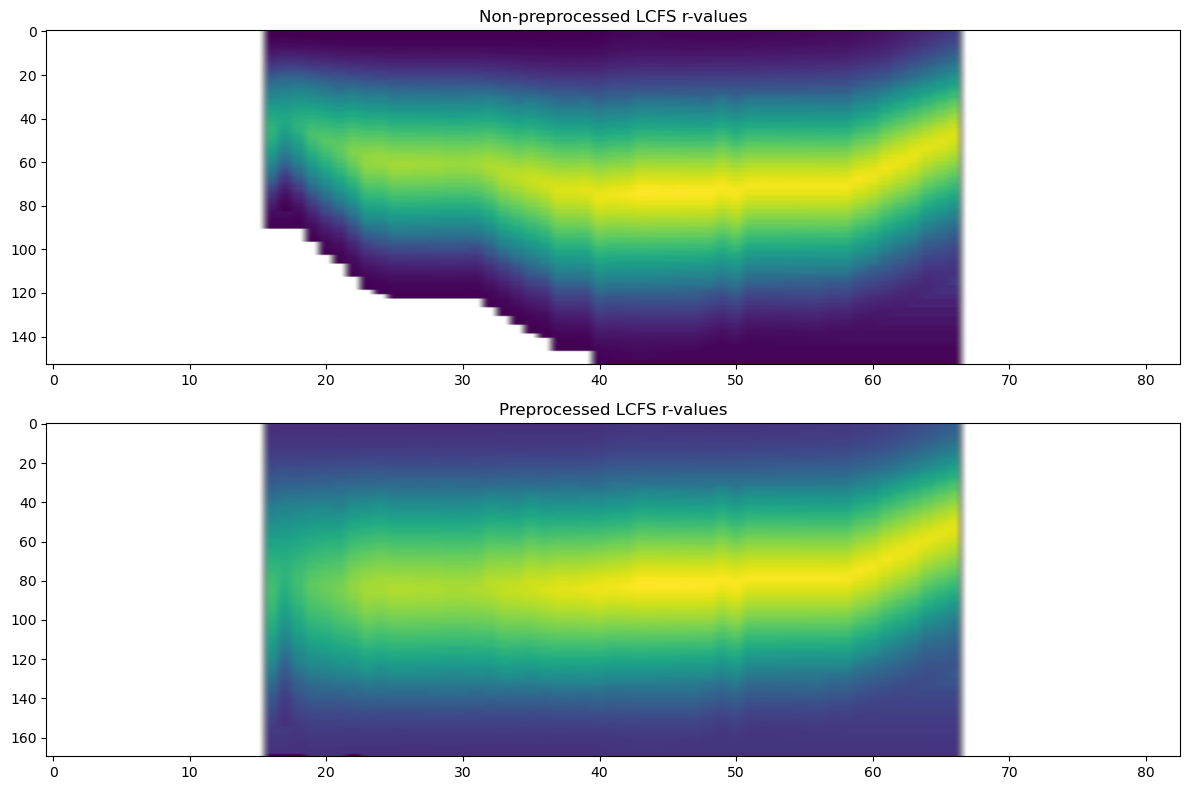

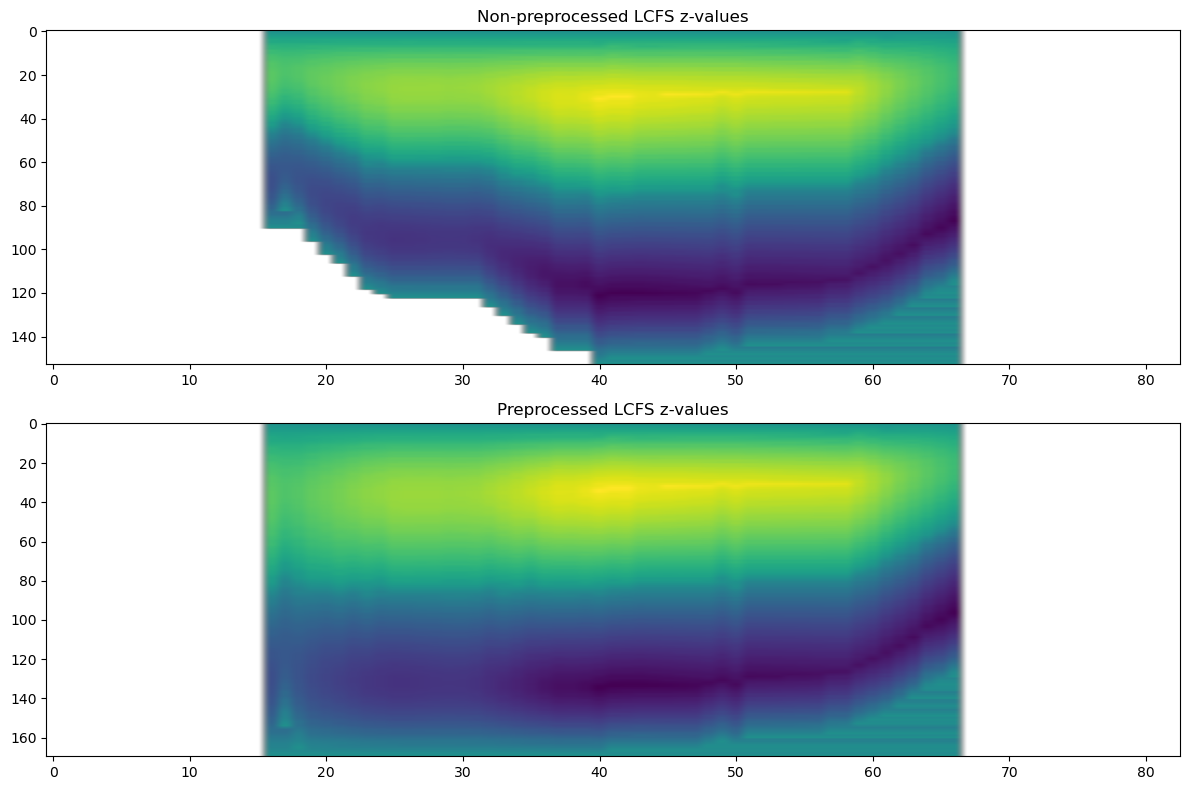

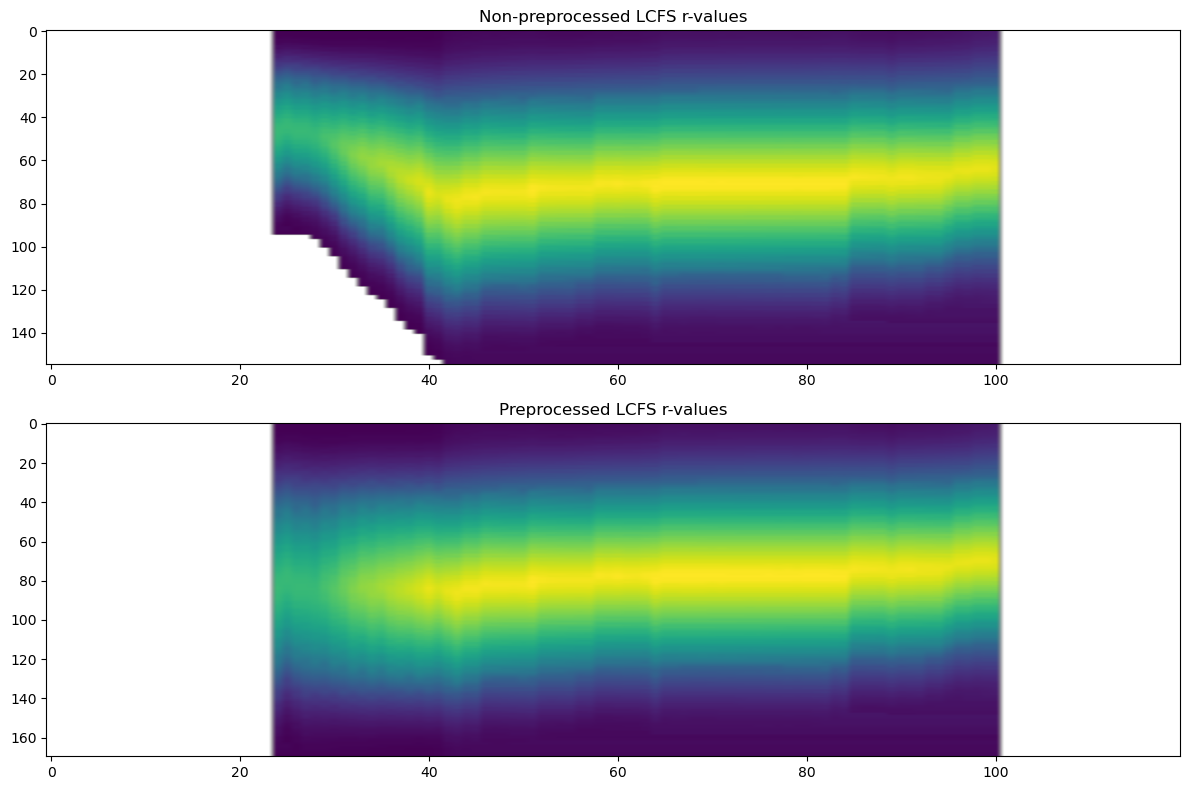

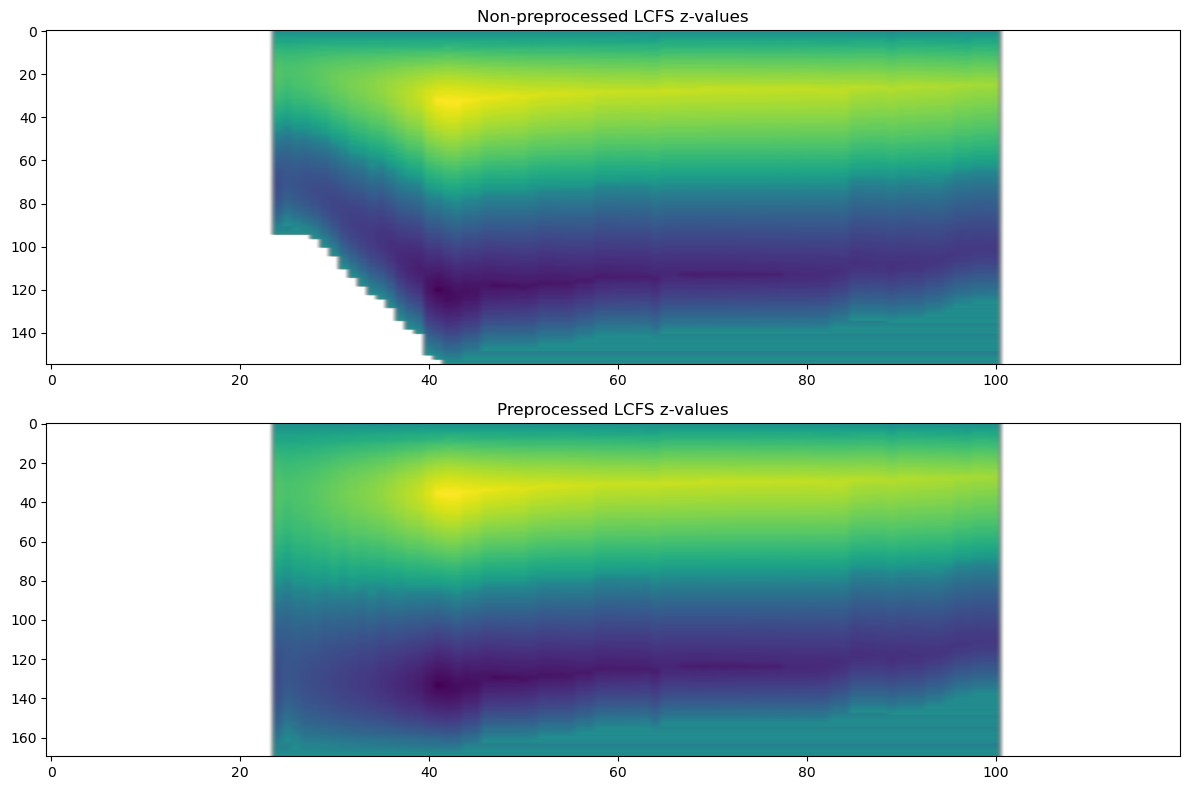

In [4]:
for non_pr_data, pr_data in zip(non_preprocessed_train_dataset, preprocessed_train_dataset):
    
    # === LCFS r-values ===
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # taller figure
    axes[0].imshow(non_pr_data["equilibrium-lcfs_r"]["values"], aspect="auto")
    axes[0].set_title("Non-preprocessed LCFS r-values")
    
    axes[1].imshow(pr_data["equilibrium-lcfs_r"]["values"], aspect="auto")
    axes[1].set_title("Preprocessed LCFS r-values")
    
    plt.tight_layout()
    plt.show()
    
    # === LCFS z-values ===
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # taller figure
    axes[0].imshow(non_pr_data["equilibrium-lcfs_z"]["values"], aspect="auto")
    axes[0].set_title("Non-preprocessed LCFS z-values")
    
    axes[1].imshow(pr_data["equilibrium-lcfs_z"]["values"], aspect="auto")
    axes[1].set_title("Preprocessed LCFS z-values")
    
    plt.tight_layout()
    plt.show()


## Standardscaling Example

In [18]:
# ..................................................................................................................
# Specific Data Preprocessing for LCFS profiles 

import pickle
from scripts.pipelines.transforms.signal_level_transforms.pretrained_stdscale_normalize_transform import (
    StdScalingTransform
)

source_signal_list_ = [
    ('equilibrium','elongation'), 
    ('equilibrium','lcfs_z')]

mean_path = "../metadata/2025-09-09_stdscaling info/dict_mean_shot.pkl"
std_path = "../metadata/2025-09-09_stdscaling info/dict_std_shot.pkl"

with open(mean_path, "rb") as f:  # 'rb' = read binary
    dict_mean = pickle.load(f)
with open(std_path, "rb") as f:  # 'rb' = read binary
    dict_std = pickle.load(f)

signal_transform_map = {
    var: None for var in [f'{source}-{signal}' for source, signal in source_signal_list_] }
signal_transform_map['equilibrium-elongation'] = ComposeTransforms([])
signal_transform_map['equilibrium-lcfs_z'] = ComposeTransforms([ReshapeLcfsTransform()])

stdscaled_signal_transform_map = {
    var: None for var in [f'{source}-{signal}' for source, signal in source_signal_list_] }
stdscaled_signal_transform_map['equilibrium-elongation'] = ComposeTransforms([StdScalingTransform(dict_mean['equilibrium-elongation'], 
                                                                                                  dict_std['equilibrium-elongation'])])
stdscaled_signal_transform_map['equilibrium-lcfs_z'] = ComposeTransforms([ReshapeLcfsTransform(), 
                                                                          StdScalingTransform(dict_mean['equilibrium-lcfs_z'], 
                                                                                              dict_std['equilibrium-lcfs_z'])])

non_preprocessed_train_dataset = MastDataset(
    local=LOCAL_FLAG,
    shots_list=train_sh,
    source_signal_list=source_signal_list_,
    signal_level_transform_map=signal_transform_map,
    shot_level_transform=None
)

stdscaled_train_dataset = MastDataset(
    local=LOCAL_FLAG,
    shots_list=train_sh,
    source_signal_list=source_signal_list_,
    signal_level_transform_map=stdscaled_signal_transform_map,
    shot_level_transform=None
)

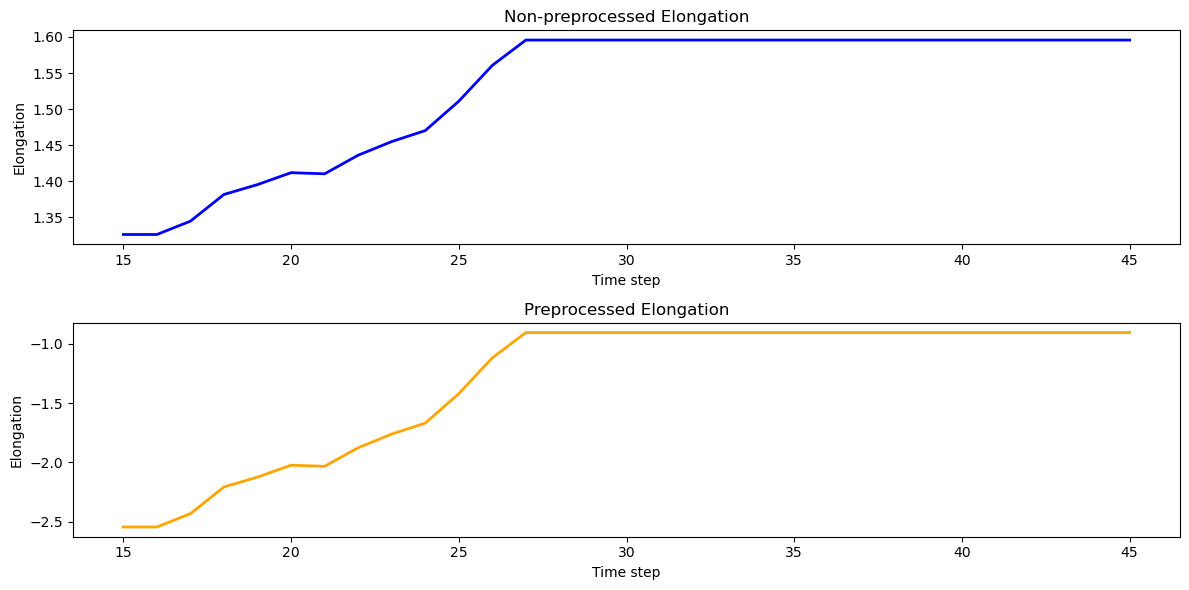

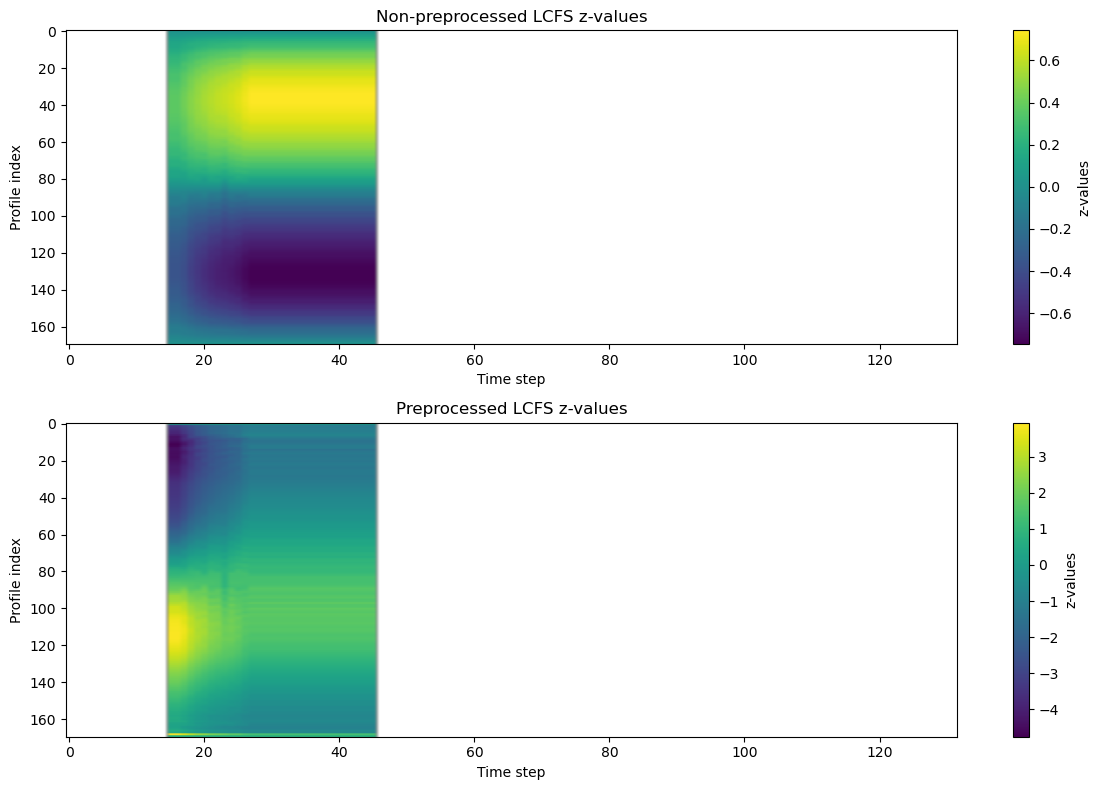

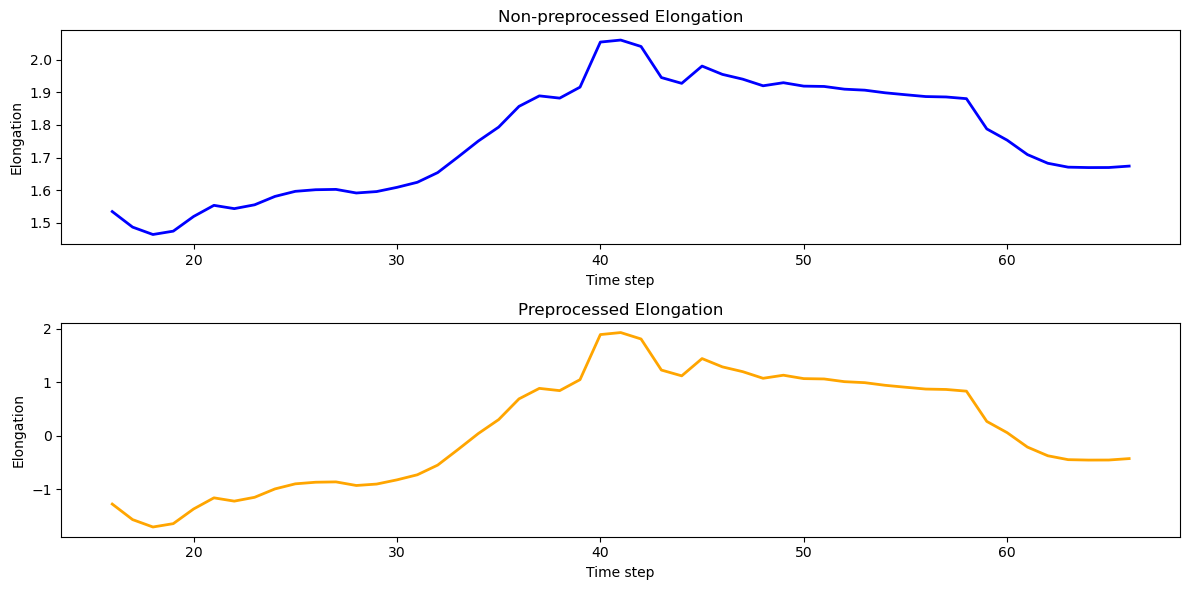

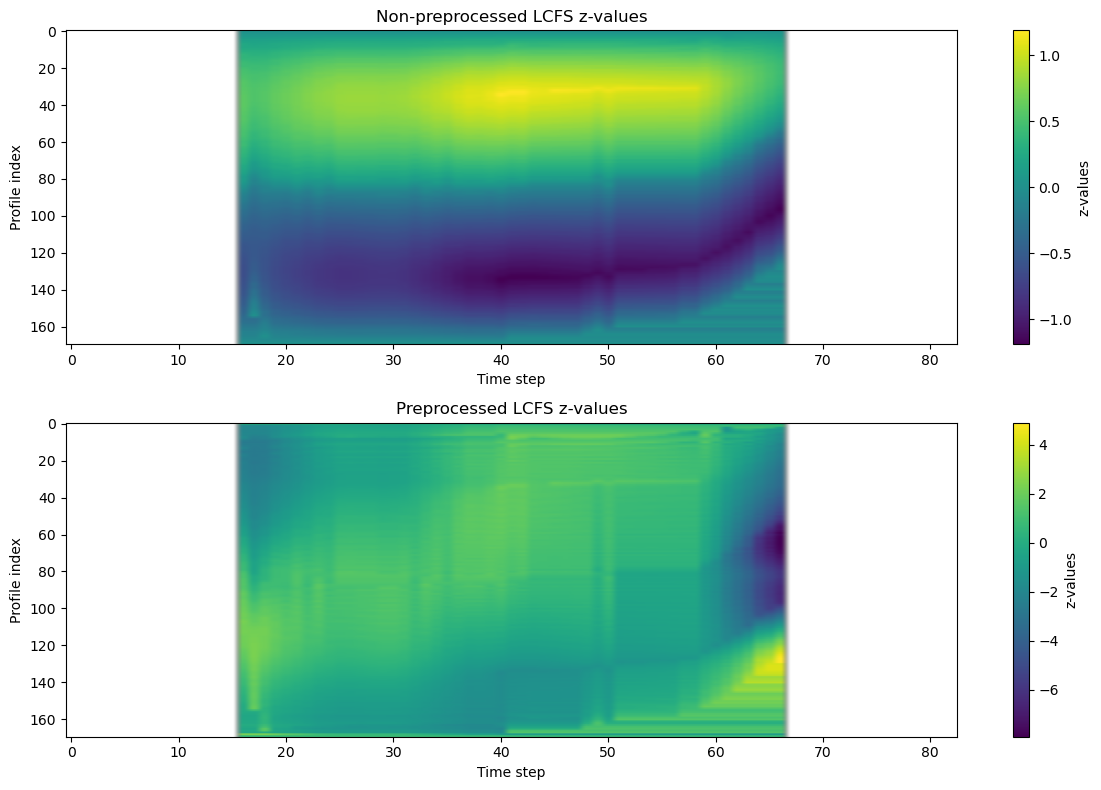

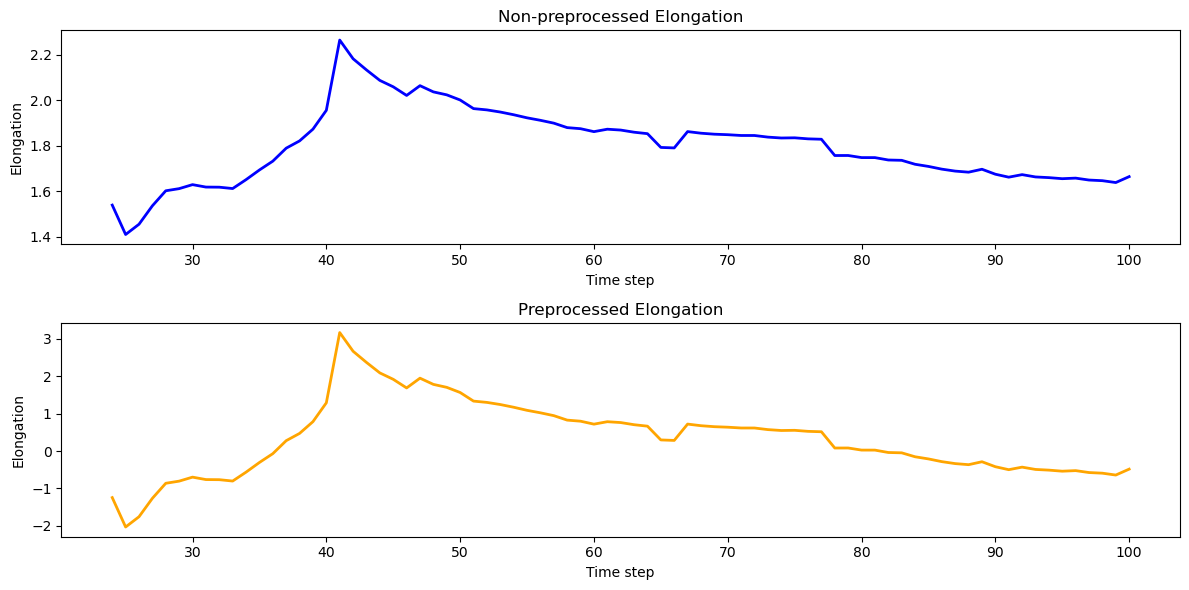

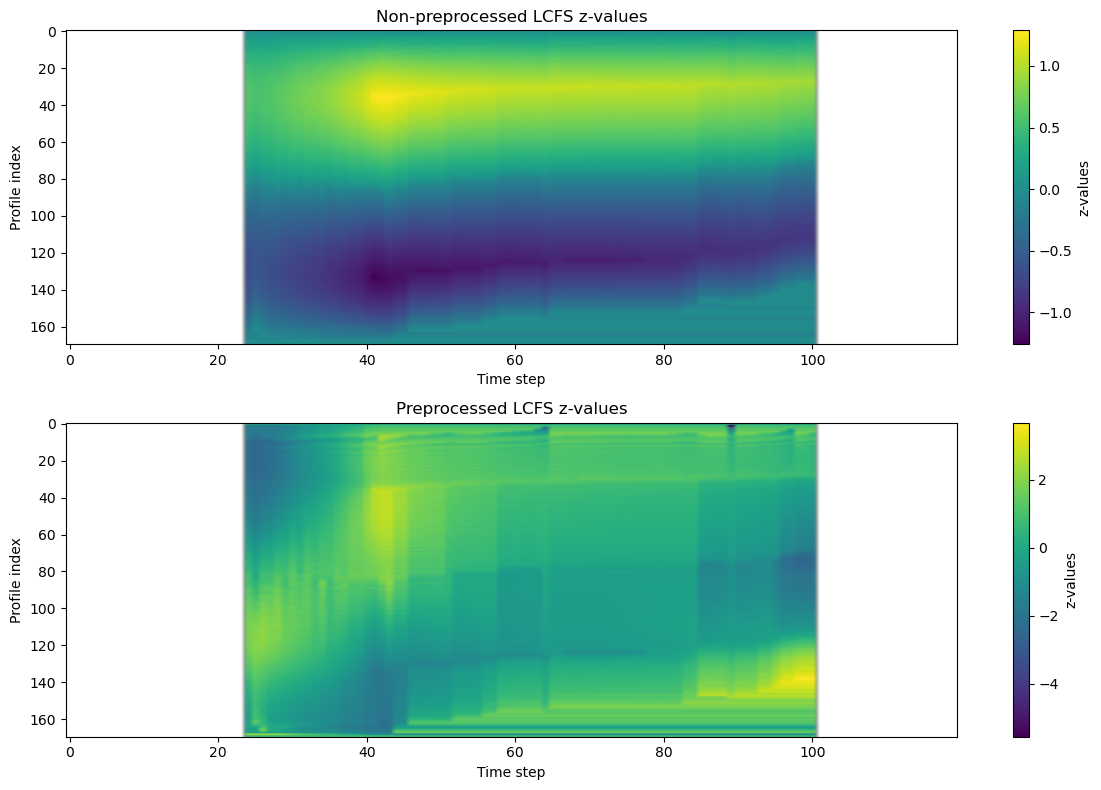

In [21]:
for non_pr_data, pr_data in zip(non_preprocessed_train_dataset, stdscaled_train_dataset):
    
    # === Elongation (time series) ===
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))  # taller figure for time series
    
    # Non-preprocessed elongation
    axes[0].plot(non_pr_data["equilibrium-elongation"]["values"].T, color='blue', lw=2)
    axes[0].set_title("Non-preprocessed Elongation")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Elongation")
    
    # Preprocessed elongation
    axes[1].plot(pr_data["equilibrium-elongation"]["values"].T, color='orange', lw=2)
    axes[1].set_title("Preprocessed Elongation")
    axes[1].set_xlabel("Time step")
    axes[1].set_ylabel("Elongation")
    
    plt.tight_layout()
    plt.show()
    
    # === LCFS z-values (2D profiles) ===
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Non-preprocessed
    im0 = axes[0].imshow(non_pr_data["equilibrium-lcfs_z"]["values"], aspect="auto")
    axes[0].set_title("Non-preprocessed LCFS z-values")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Profile index")
    fig.colorbar(im0, ax=axes[0], orientation='vertical', label="z-values")
    
    # Preprocessed
    im1 = axes[1].imshow(pr_data["equilibrium-lcfs_z"]["values"], aspect="auto")
    axes[1].set_title("Preprocessed LCFS z-values")
    axes[1].set_xlabel("Time step")
    axes[1].set_ylabel("Profile index")
    fig.colorbar(im1, ax=axes[1], orientation='vertical', label="z-values")
    
    plt.tight_layout()
    plt.show()
